# The Impact of Kalman Filter Transition Model Selection on the Effectiveness of Long-Term Correlated Time Series Reconstruction
PIERE 2026

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from scipy import stats
from statsmodels.tsa.stattools import acf
from tqdm import tqdm

from research.kalman_filter.reconstruction_of_long_term_complex_system_dynamics.gen_filter_save import (
    get_F_kinematic,
    get_F_matrix_yw,
)
from StatTools.generators import generate_fbn

In [2]:
DATA_DIR = Path("research/kalman_filter/piere2026")
SIGNALS_DIR = Path(
    "research/kalman_filter/piere2026/output/signals"
)  # 8 random series were generated independently for each target value H using the python script research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/gen_filter_save.py
OUTPUT_DATA_DIR = DATA_DIR / "output"
H_LIST: list[float] = [0.8, 1.0, 1.2, 1.4]
NOISE_RATIOS: list[float] = [0.1, 0.3, 0.5, 0.7, 0.9, 2.0, 3.0]
SIGNALS_COUNT: int = 8
ORDERS: list[int] = [2, 4, 8]

In [3]:
def normalize(data: np.ndarray[np.float64]) -> np.ndarray[np.float64]:
    mean = np.nanmean(data)
    std = np.nanstd(data)
    return (data - mean) / std if std != 0 else (data - mean)


def _compute_mse(reference: np.ndarray, signal: np.ndarray) -> float:
    return float(np.mean((np.asarray(reference) - np.asarray(signal)) ** 2))


def _compute_one_signal_r_mse(hi, model_h, signal_idx, ni, nr, method, order):
    signal_o = normalize(
        np.load(SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy")
    )
    signal_r = normalize(
        np.load(
            SIGNALS_DIR
            / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{model_h}.npy"
        )
    )
    mse = _compute_mse(signal_o, signal_r)
    r, p_value = stats.pearsonr(signal_o, signal_r)
    return hi, model_h, signal_idx, ni, nr, mse, r, p_value

## Plot signals

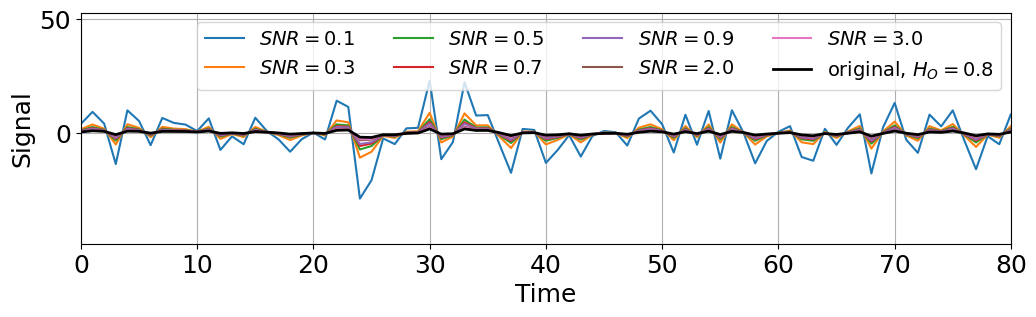

In [4]:
plt.figure(figsize=(12, 3))
model_h = 0.8
signal_idx = 1
for noise_ratio in NOISE_RATIOS:
    signal_path = SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy"
    noisy_path = SIGNALS_DIR / f"noisy_hm{model_h}_{signal_idx}_nr{noise_ratio}.npy"

    plt.plot(np.load(noisy_path), label=f"$SNR={noise_ratio}$")
plt.plot(
    np.load(signal_path), label=f"original, $H_O={model_h}$", color="black", linewidth=2
)
plt.xlabel("Time", fontsize=18)
plt.ylabel("Signal", fontsize=18)
plt.legend(fontsize=14, ncols=4)
plt.tick_params(labelsize=18)
plt.grid(True)
plt.xlim(0, 80)
plt.savefig(
    f"research/kalman_filter/piere2026/output/noises_h{model_h}.svg",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

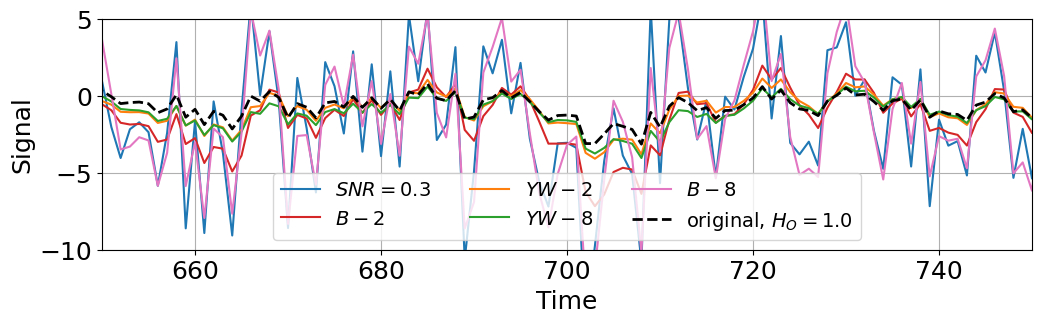

In [5]:
plt.figure(figsize=(12, 3))
model_h = 1.0
noise_ratio = 0.3
signal_path = SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy"
noisy_path = SIGNALS_DIR / f"noisy_hm{model_h}_{signal_idx}_nr{noise_ratio}.npy"

order = 2
yw2_signal = (
    SIGNALS_DIR
    / f"recovered_hm{model_h}_{signal_idx}_nr{noise_ratio}_YW_o{order}_hf{model_h}.npy"
)
b2_signal = (
    SIGNALS_DIR
    / f"recovered_hm{model_h}_{signal_idx}_nr{noise_ratio}_Baseline_o{order}_hf{model_h}.npy"
)

plt.plot(np.load(noisy_path), label=f"$SNR={noise_ratio}$")
plt.plot(np.load(b2_signal), label=f"$B-{order}$", color="tab:red")
plt.plot(np.load(yw2_signal), label=f"$YW-{order}$", color="tab:orange")

order = 8
yw8_signal = (
    SIGNALS_DIR
    / f"recovered_hm{model_h}_{signal_idx}_nr{noise_ratio}_YW_o{order}_hf{model_h}.npy"
)
b8_signal = (
    SIGNALS_DIR
    / f"recovered_hm{model_h}_{signal_idx}_nr{noise_ratio}_Baseline_o{order}_hf{model_h}.npy"
)
plt.plot(np.load(yw8_signal), label=f"$YW-{order}$", color="tab:green")
plt.plot(np.load(b8_signal), label=f"$B-{order}$", color="tab:pink")

plt.plot(
    np.load(signal_path),
    label=f"original, $H_O={model_h}$",
    color="black",
    linewidth=2,
    linestyle="dashed",
)
plt.xlabel("Time", fontsize=18)
plt.ylabel("Signal", fontsize=18)
plt.legend(fontsize=14, ncols=3)
plt.tick_params(labelsize=18)
plt.grid(True)
plt.xlim(650, 750)
plt.ylim(-10, 5)
plt.savefig(
    f"research/kalman_filter/piere2026/output/rec_h{model_h}.svg",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

## Pirson / MSE

In [6]:
all_records = []

methods_to_test = ["YW", "Baseline"]
orders_to_test = [2, 4, 8]

for method in methods_to_test:
    for order in orders_to_test:
        print(f"Processing: method={method}, order={order}")

        tasks = [
            (hi, model_h, signal_idx, ni, nr, method, order)
            for hi, model_h in enumerate(H_LIST)
            for signal_idx in range(SIGNALS_COUNT)
            for ni, nr in enumerate(NOISE_RATIOS)
        ]

        results = Parallel(n_jobs=-1)(
            delayed(_compute_one_signal_r_mse)(*t) for t in tqdm(tasks)
        )

        for hi, model_h, signal_idx, ni, nr, mse, r, p_value in results:
            all_records.append(
                {
                    "method": method,
                    "order": order,
                    "H_O": model_h,
                    "noise_ratio": nr,
                    "signal_idx": signal_idx,
                    "mse": mse,
                    "r": round(r, 3),
                    "p_value": round(p_value, 4),
                }
            )

metrics_df = pd.DataFrame(all_records)

Processing: method=YW, order=2


100%|██████████| 224/224 [00:03<00:00, 73.16it/s] 


Processing: method=YW, order=4


100%|██████████| 224/224 [00:00<00:00, 2403.49it/s]


Processing: method=YW, order=8


...

100%|██████████| 224/224 [00:00<00:00, 1868.44it/s]


Processing: method=Baseline, order=4


100%|██████████| 224/224 [00:00<00:00, 2153.70it/s]


Processing: method=Baseline, order=8


100%|██████████| 224/224 [00:00<00:00, 2464.47it/s]


In [7]:
metrics_df

,method,order,H_O,noise_ratio,signal_idx,mse,r,p_value
0,YW,2,0.8,0.1,0,0.080920,0.960,0.0
1,YW,2,0.8,0.3,0,0.054758,0.973,0.0
2,YW,2,0.8,0.5,0,0.032714,0.984,0.0
3,YW,2,0.8,0.7,0,0.021764,0.989,0.0
4,YW,2,0.8,0.9,0,0.015819,0.992,0.0
...,...,...,...,...,...,...,...,...
1339,Baseline,8,1.4,0.5,7,0.970606,0.515,0.0
1340,Baseline,8,1.4,0.7,7,0.740855,0.630,0.0
1341,Baseline,8,1.4,0.9,7,0.573606,0.713,0.0
1342,Baseline,8,1.4,2.0,7,0.189901,0.905,0.0


In [8]:
h_values = sorted(metrics_df["H_O"].unique())
noise_values = sorted(metrics_df["noise_ratio"].unique())
orders = sorted(metrics_df["order"].unique())

14:59:27  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:59:27  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


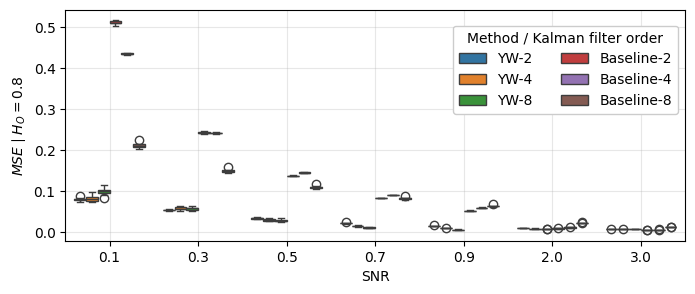

14:59:27  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:59:27  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


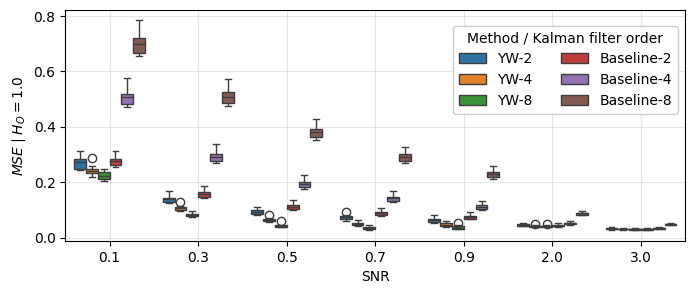

14:59:27  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:59:27  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


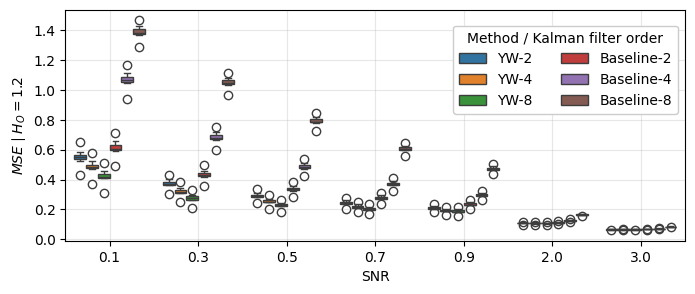

14:59:28  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:59:28  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


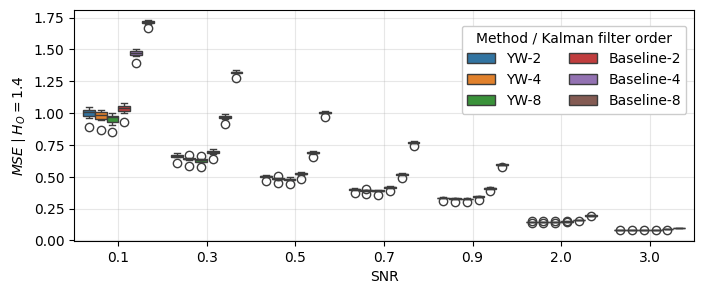

In [9]:
metric = "mse"
handles = None
labels = None

metrics_df["config"] = np.where(
    metrics_df["method"] == "Baseline",
    "Baseline-" + metrics_df["order"].astype(str),
    "YW-" + metrics_df["order"].astype(str),
)
config_order = ["YW-2", "YW-4", "YW-8", "Baseline-2", "Baseline-4", "Baseline-8"]

for i, h in enumerate(h_values):
    fig, ax = plt.subplots(figsize=(8, 3), sharex=True)
    subset = metrics_df[metrics_df["H_O"] == h]

    boxplot = sns.boxplot(
        data=subset,
        x="noise_ratio",
        y=metric,
        hue="config",
        hue_order=config_order,
        palette="tab10",
        ax=ax,
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.set_ylabel(f"$MSE \\mid H_O = {h}$")
    ax.set_xlabel("SNR")
    ax.grid(True, alpha=0.3)

    ax.legend_.remove()

    fig.legend(
        handles,
        labels,
        title="Method / Kalman filter order",
        loc="upper center",
        # bbox_to_anchor=(0.7, 0.5), #for r
        bbox_to_anchor=(0.75, 0.85),  # for mse
        ncol=2,
        framealpha=1.0,
    )

    plt.subplots_adjust(hspace=0.05)
    plt.savefig(OUTPUT_DATA_DIR / f"{metric}_h{h}_synth.png", bbox_inches="tight")
    plt.savefig(OUTPUT_DATA_DIR / f"{metric}_h{h}synth.svg", bbox_inches="tight")
    plt.show()

## ACF

In [10]:
ACF_H_LIST = [0.8, 1.0, 1.2]
ACF_NOISE_RATIOS = [0.3]
N_LAGS = 300
signal_idx = 5
nr = ACF_NOISE_RATIOS[0]
lags = np.arange(1, N_LAGS + 2)
lift = 1.3

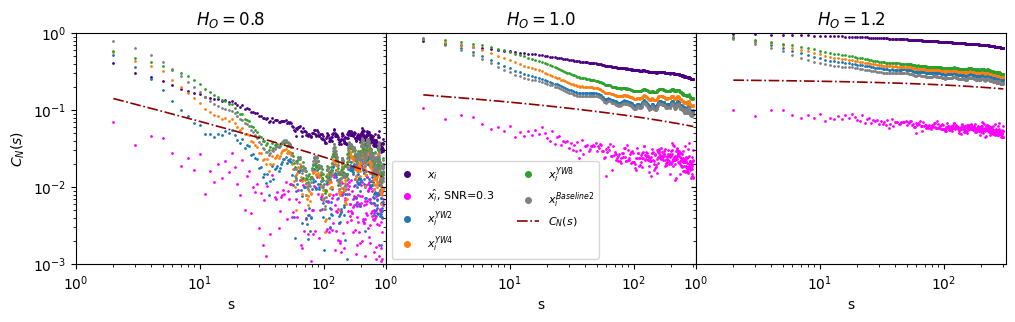

In [11]:
fig, axes = plt.subplots(
    1, len(ACF_H_LIST), figsize=(4 * len(ACF_H_LIST), 3), sharey=True
)

for ax, model_h in zip(axes, ACF_H_LIST):
    gamma = 2 - 2 * model_h
    power_law = lags.astype(float) ** (-gamma)

    # without noise
    signal = np.load(SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy")
    signal_acf = acf(signal, nlags=N_LAGS)

    shift_clean = signal_acf[1] / power_law[1]

    # finite-size theoretical ACF, Eq. (21) of Lennartz & Bunde (2009):
    # C_N(s) = [(2-gamma)(1-gamma)/2 * s^-gamma - N^-gamma] / (1 - N^-gamma)
    # (a=0, no additive white noise -- already correctly normalized, no shift needed)
    N_signal = len(signal)
    if np.isclose(gamma, 0.0):
        # gamma = 2-2H = 0 (H=1.0) is a removable 0/0 singularity in the general
        # formula. Closed-form limit via L'Hopital / Taylor expansion around
        # gamma=0: C_N(s) -> (ln(N/s) - 1.5) / ln(N). Verified numerically to
        # match the general formula evaluated at gamma=1e-8 to 6 decimal places.
        finite_size_acf = (np.log(N_signal / lags.astype(float)) - 1.5) / np.log(
            N_signal
        )
    else:
        finite_size_acf = (
            (2 - gamma) * (1 - gamma) / 2 * lags.astype(float) ** (-gamma)
            - N_signal ** (-gamma)
        ) / (1 - N_signal ** (-gamma))

    ax.plot(
        lags[1:],
        signal_acf[1:],
        marker=".",
        linestyle="none",
        color="indigo",
        label="$x_i$",
        markersize=2,
    )

    # with noise
    noisy_signal = np.load(SIGNALS_DIR / f"noisy_hm{model_h}_{signal_idx}_nr{nr}.npy")
    noisy_acf = acf(noisy_signal, nlags=N_LAGS)

    ax.plot(
        lags[1:],
        noisy_acf[1:],
        marker=".",
        linestyle="none",
        color="magenta",
        label=f"$\\hat{{x_i}}$, SNR={nr}",
        markersize=2,
    )

    # filtred
    method = "YW"
    for i, order in enumerate(ORDERS):
        filtred_signal = np.load(
            SIGNALS_DIR
            / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{model_h}.npy"
        )
        filtred_acf = acf(filtred_signal, nlags=N_LAGS)
        ax.plot(
            lags[1:],
            filtred_acf[1:],
            marker=".",
            linestyle="none",
            label=f"$x_i^{{{method}{order}}}$",
            color=sns.color_palette("tab10", len(ORDERS))[i],
            markersize=2,
        )

    method = "Baseline"
    order = 2
    baseline_signal = np.load(
        SIGNALS_DIR
        / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{model_h}.npy"
    )
    baseline_acf = acf(baseline_signal, nlags=N_LAGS)
    ax.plot(
        lags[1:],
        baseline_acf[1:],
        marker=".",
        linestyle="none",
        label=f"$x_i^{{{method}{order}}}$",
        color="gray",
        markersize=2,
    )

    finite_size_acf_lift = 0.3
    if model_h == 0.8:
        finite_size_acf_lift = 0.4
    if model_h == 1.0:
        finite_size_acf_lift = 0.2
    if model_h == 1.2:
        finite_size_acf_lift = 0.25

    ax.plot(
        lags[1:],
        finite_size_acf[1:] * finite_size_acf_lift,
        linestyle="-.",
        color="darkred",
        linewidth=1.2,
        label=r"$C_N(s)$",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(10**0, 10 ** (2.5))
    ax.set_ylim(10 ** (-3), 10**0)
    ax.set_xlabel("s")
    ax.set_title(f"$H_O={model_h:.1f}$")

axes[1].legend(ncols=2, fontsize=8, markerscale=4)

axes[0].set_ylabel("$C_N(s)$")
plt.subplots_adjust(wspace=0)
plt.savefig(OUTPUT_DATA_DIR / "acf_filtred.png", bbox_inches="tight", pad_inches=0.1)
plt.savefig(OUTPUT_DATA_DIR / "acf_filtred.svg", bbox_inches="tight", pad_inches=0.1)
plt.show()

## Matrices in numerical form

In [12]:
get_F_kinematic(2)

array([[1., 1.],
       [0., 1.]])

In [13]:
signal = generate_fbn(
    hurst=0.8,
    length=2**15,
    method="kasdin",
    filter_type="lfilter_truncated",
)[0]
np.round(get_F_matrix_yw(signal, 2), 3)

array([[0.357, 0.184],
       [1.   , 0.   ]])

In [14]:
np.round(get_F_kinematic(4), 3)

array([[1.   , 1.   , 0.5  , 0.167],
       [0.   , 1.   , 1.   , 0.5  ],
       [0.   , 0.   , 1.   , 1.   ],
       [0.   , 0.   , 0.   , 1.   ]])

In [15]:
np.round(get_F_matrix_yw(signal, 4), 3)

array([[0.325, 0.131, 0.08 , 0.095],
       [1.   , 0.   , 0.   , 0.   ],
       [0.   , 1.   , 0.   , 0.   ],
       [0.   , 0.   , 1.   , 0.   ]])